# ARIMA Model training

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

from tqdm.auto import tqdm


## Load Dataset

In [ ]:
df = pd.read_csv("/content/all_bank_stock_data.csv")

In [ ]:
df.head(5)

,Date,Bank,Open,High,Low,Close,Volume
0,NaN,NaN,LLOY.L,LLOY.L,LLOY.L,LLOY.L,LLOY.L
1,2015-01-02,Lloyds,76.11351372005572,76.39220720232863,75.31624532740311,75.79500579833984,54277932
2,2015-01-05,Lloyds,75.71538565801829,76.04384912596093,74.11289035617187,74.27214813232422,102525515
3,2015-01-06,Lloyds,74.28209387862202,74.70014173189884,72.53030395507812,72.53030395507812,133810250
4,2015-01-07,Lloyds,72.978191980182,73.59828873371622,72.5302928555775,72.66963958740234,108980419


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8632 entries, 0 to 8631
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    8629 non-null   object
 1   Bank    8629 non-null   object
 2   Open    8632 non-null   object
 3   High    8632 non-null   object
 4   Low     8632 non-null   object
 5   Close   8632 non-null   object
 6   Volume  8632 non-null   object
dtypes: object(7)
memory usage: 472.2+ KB


In [ ]:
df.describe()

,Date,Bank,Open,High,Low,Close,Volume
count,8629,8629,8632,8632,8632,8632,8632
unique,2933,3,8628,8624,8629,8241,8502
top,2026-05-18,Lloyds,390.0,99.69000244140625,417.0,66.76242065429688,3097800
freq,3,2881,2,2,2,4,4


## Selecting One Bank

In [ ]:
lloyds = pd.read_csv("/content/lloyds_bank_stock_data.csv", skiprows=[1])

barclays = pd.read_csv("/content/barclays_bank_stock_data.csv", skiprows=[1])

goldman = pd.read_csv("/content/gs_bank_stock_data.csv", skiprows=[1])

In [ ]:
lloyds = pd.read_csv(
    "/content/lloyds_bank_stock_data.csv",
    skiprows=[1]
)

print(lloyds.head(5))
print(lloyds.columns)

         Date      Close       High        Low       Open     Volume    Bank
0  2015-01-02  75.795006  76.392207  75.316245  76.113514   54277932  Lloyds
1  2015-01-05  74.272148  76.043849  74.112890  75.715386  102525515  Lloyds
2  2015-01-06  72.530304  74.700142  72.530304  74.282094  133810250  Lloyds
3  2015-01-07  72.669640  73.598289  72.530293  72.978192  108980419  Lloyds
4  2015-01-08  73.754562  74.073070  72.908526  73.167316   79367070  Lloyds
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Bank'], dtype='object')


## Clean the Data

### Convert Date Column

In [ ]:
for _bank_df in (lloyds, barclays, goldman):
    _bank_df["Date"] = pd.to_datetime(_bank_df["Date"])

    numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
    _bank_df[numeric_cols] = _bank_df[numeric_cols].apply(pd.to_numeric)

    _bank_df.sort_values("Date", inplace=True)
    _bank_df.set_index("Date", inplace=True)

## Keep Only Closing Price

In [ ]:
series = lloyds['Close']

In [ ]:
lloyds.head(5)
lloyds.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2881 entries, 2015-01-02 to 2026-05-29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2881 non-null   float64
 1   High    2881 non-null   float64
 2   Low     2881 non-null   float64
 3   Open    2881 non-null   float64
 4   Volume  2881 non-null   int64  
 5   Bank    2881 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 157.6+ KB


## Exploratory Time Series Analysis (EDA)

In [ ]:
print(lloyds.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
Bank      0
dtype: int64


In [ ]:
lloyds.describe()

,Close,High,Low,Open,Volume
count,2881.000000,2881.000000,2881.000000,2881.000000,2.881000e+03
mean,58.699511,59.395439,58.018919,58.713569,1.874855e+08
std,16.281308,16.346751,16.189309,16.303127,9.718606e+07
min,23.919664,24.677754,23.525660,23.979512,1.811624e+07
25%,46.287598,46.921542,45.763533,46.370666,1.230623e+08
50%,57.631748,58.277982,56.994642,57.642642,1.644424e+08
75%,67.709053,68.366704,67.037449,67.798745,2.251501e+08
max,112.573212,114.572735,112.023346,113.423007,7.669057e+08


## Plot the Closing Price

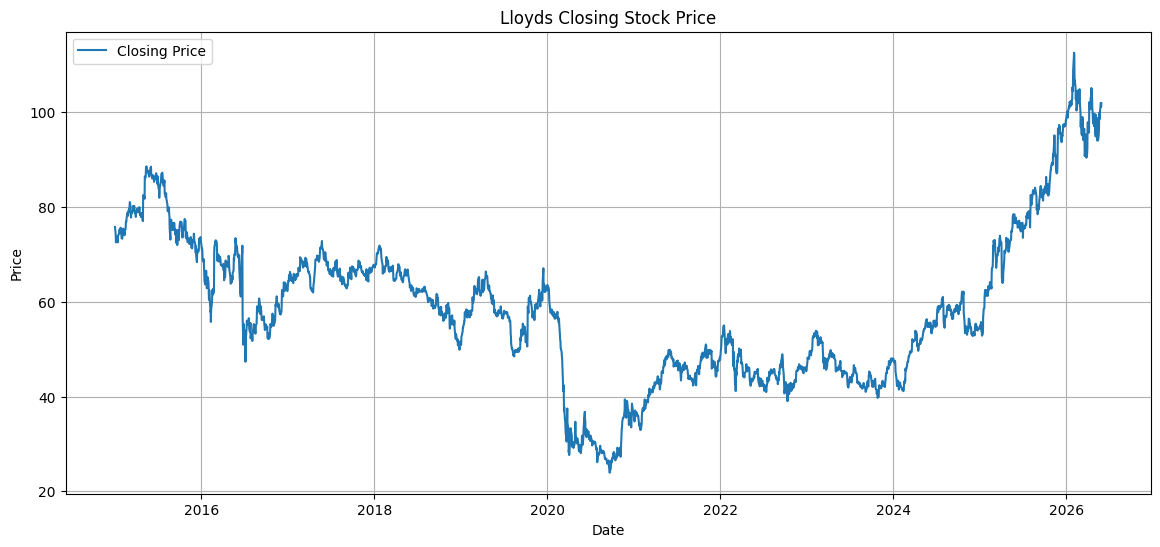

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(lloyds.index, lloyds["Close"], label="Closing Price")

plt.title("Lloyds Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.grid(True)

plt.show()

## Plot Trading Volume

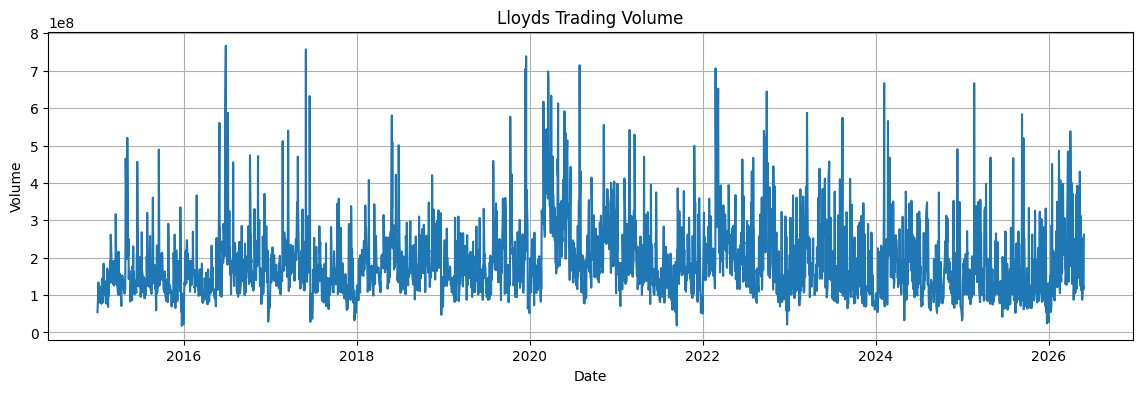

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(lloyds.index, lloyds["Volume"])

plt.title("Lloyds Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

## Check Stationarity (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])
print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -0.7507383944253768
p-value       : 0.8331659564945051

Critical Values:
1%: -3.432637723482569
5%: -2.862550760151631
10%: -2.567308057261285


| p-value    | Conclusion                                              |
| ---------- | ------------------------------------------------------- |
| **< 0.05** | The series is stationary. No differencing is required.  |
| **> 0.05** | The series is non-stationary. Differencing is required. |


ADF Test Results
Metric	Value
| Metric        |       Value |
| ------------- | ----------: |
| ADF Statistic | **-0.7507** |
| p-value       |  **0.8332** |

Interpretation

Since:

p-value = 0.8332 > 0.05

we fail to reject the null hypothesis.

Conclusion: The Lloyds closing price series is non-stationary, meaning its statistical properties (such as the mean) change over time. Therefore, differencing is required before fitting an ARIMA model.

This is actually what we expect with stock prices, so the result is completely normal.

## First-Order Differencing

In [ ]:
series_diff = series.diff().dropna()

## Visualize the Differenced Series

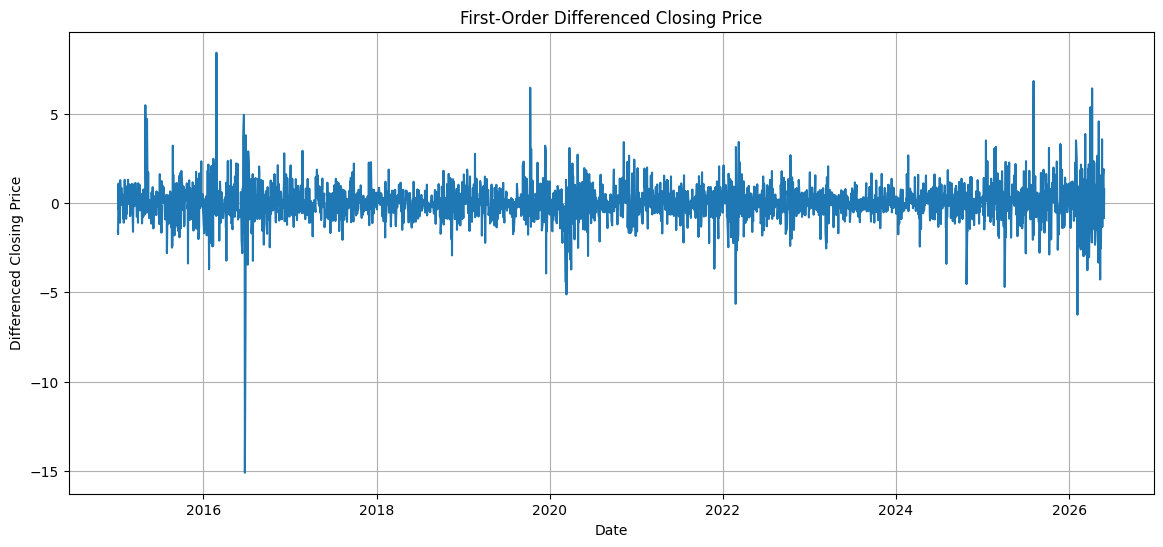

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(series_diff)

plt.title("First-Order Differenced Closing Price")
plt.xlabel("Date")
plt.ylabel("Differenced Closing Price")

plt.grid(True)
plt.show()

## ADF Test Again

In [ ]:
result = adfuller(series_diff)

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -11.983426568363965
p-value       : 3.65965490354039e-22

Critical Values:
1%: -3.432637723482569
5%: -2.862550760151631
10%: -2.567308057261285


The Augmented Dickey-Fuller (ADF) test was conducted to assess the stationarity of the Lloyds closing stock price series. The test produced an ADF statistic of -0.7507 with a p-value of 0.8332, which is greater than the significance level of 0.05. Therefore, the null hypothesis of a unit root could not be rejected, indicating that the original time series was non-stationary. To satisfy the assumptions of the ARIMA model, first-order differencing was applied before model development.

## ACF and PACF Analysis

<Figure size 1200x500 with 0 Axes>

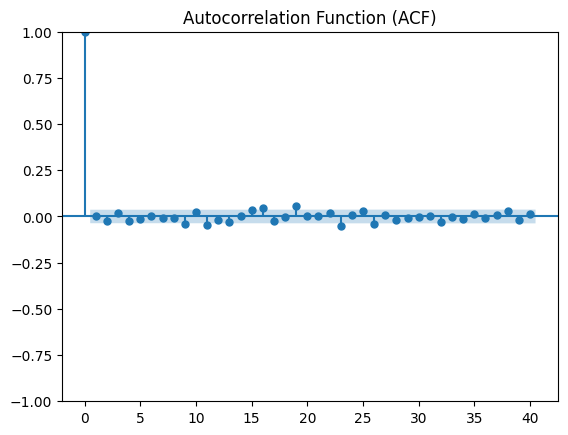

<Figure size 1200x500 with 0 Axes>

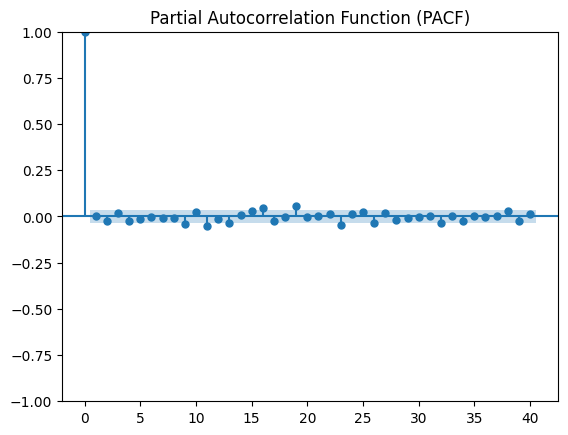

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF Plot
plt.figure(figsize=(12,5))
plot_acf(series_diff, lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# PACF Plot
plt.figure(figsize=(12,5))
plot_pacf(series_diff, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(series, order=(1,1,1))

## Train-Test Split

In [ ]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Training samples :", len(train))
print("Testing samples  :", len(test))

Training samples : 2304
Testing samples  : 577


## Grid Search for the Best ARIMA Model

In [ ]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_model = None

# Search p = 0-5, d = 1, q = 0-5
for p in range(6):
    for q in range(6):
        try:
            model = ARIMA(train, order=(p,1,q))
            results = model.fit()

            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p,1,q)
                best_model = results

        except:
            continue

print("Best ARIMA Order :", best_order)
print("Lowest AIC       :", best_aic)

Best ARIMA Order : (4, 1, 2)
Lowest AIC       : 6512.631843142553


## View the Selected Model

In [ ]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2304
Model:                 ARIMA(4, 1, 2)   Log Likelihood               -3249.316
Date:                Mon, 13 Jul 2026   AIC                           6512.632
Time:                        12:53:31   BIC                           6552.826
Sample:                             0   HQIC                          6527.285
                               - 2304                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2749      0.057      4.852      0.000       0.164       0.386
ar.L2         -0.9415      0.055    -17.236      0.000      -1.049      -0.834
ar.L3          0.0576      0.012      4.895      0.0

## Forecast

In [ ]:
history = list(train)

predictions = []

for actual in tqdm(test, desc=f"ARIMA{best_order} walk-forward (Lloyds)"):

    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]

    predictions.append(yhat)

    history.append(actual)

forecast = pd.Series(predictions, index=test.index)

ARIMA(4, 1, 2) walk-forward (Lloyds):   0%|          | 0/577 [00:00<?, ?it/s]

## Evaluation

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

mape = np.mean(np.abs((test - forecast) / test)) * 100

r2 = r2_score(test, forecast)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 0.9022
MSE  : 1.6748
RMSE : 1.2942
MAPE : 1.22%
R²   : 0.9948


## Actual vs Predicted

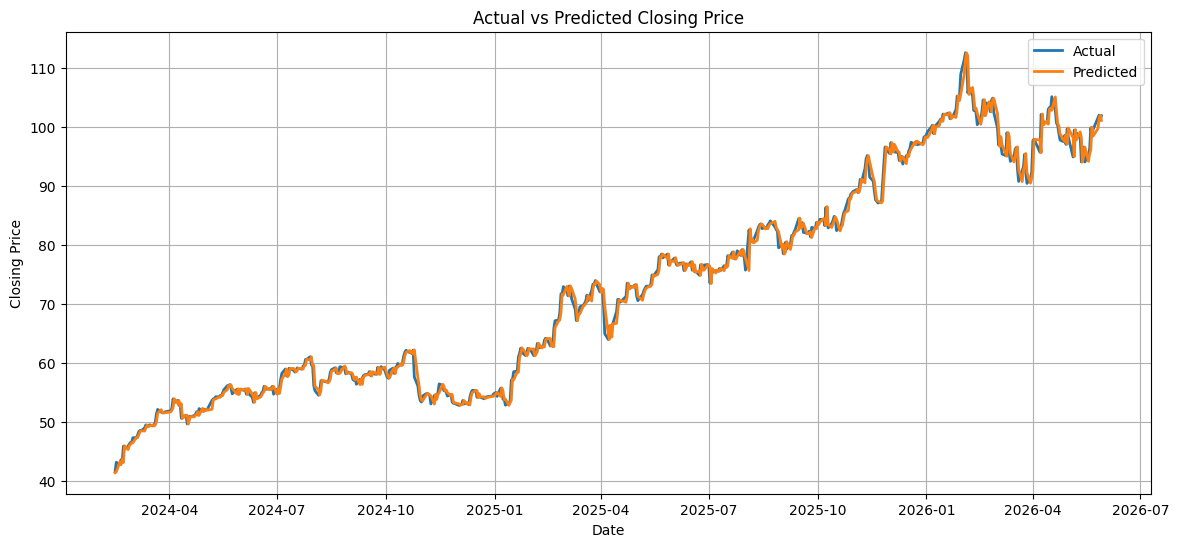

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

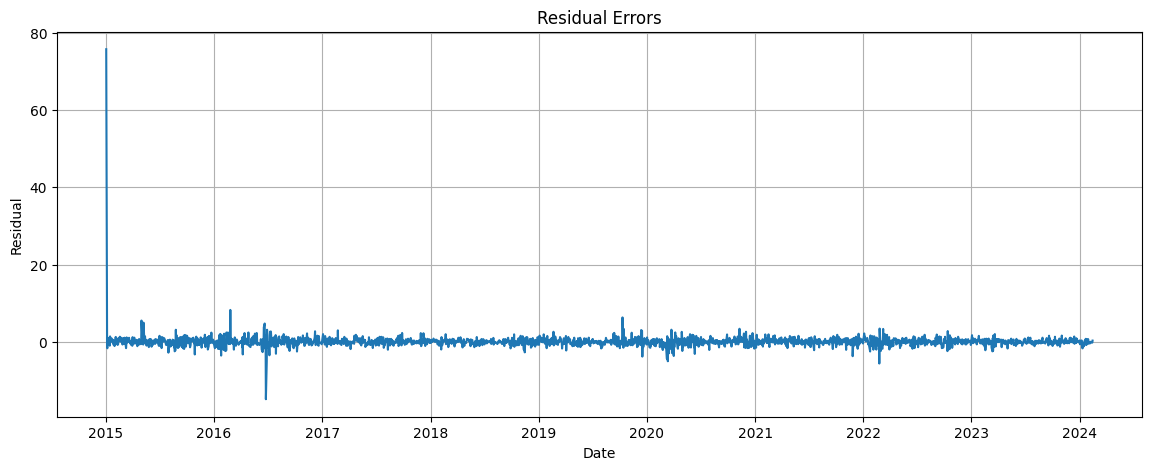

In [ ]:
residuals = best_model.resid

plt.figure(figsize=(14,5))
plt.plot(residuals)

plt.title("Residual Errors")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

## Residual Distribution

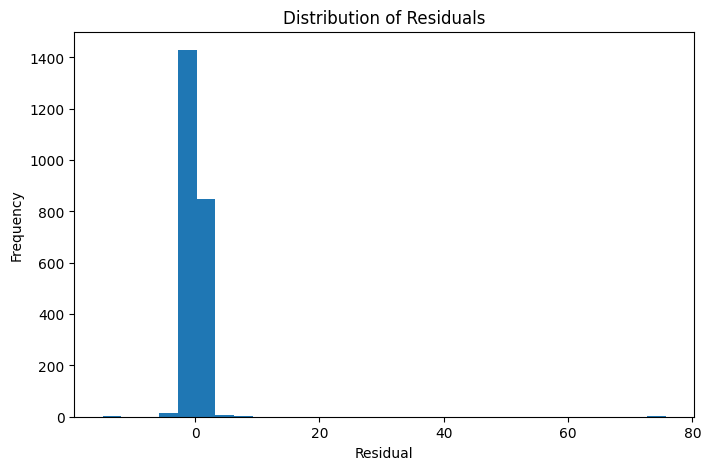

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

## Residual Autocorrelation

<Figure size 1000x400 with 0 Axes>

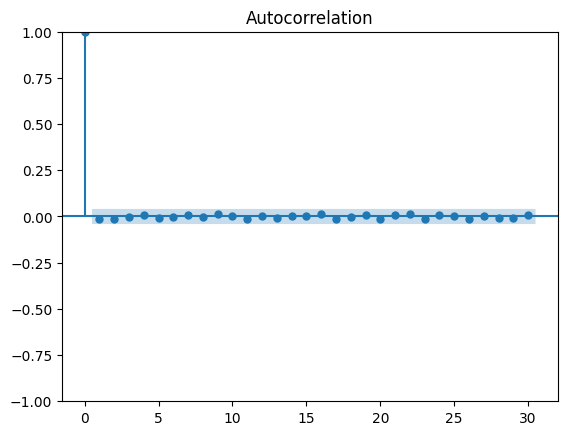

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(residuals, lags=30)
plt.show()

In [ ]:
def forecast_arima(train_series, test_series, order, refit_every=1, max_jump=0.5):
    """
    Rolling one-step-ahead walk-forward forecast, same approach used for Lloyds.

    refit_every=1 refits the model after every single observation (most accurate,
    but slowest). Set refit_every=5 or 10 to only refit periodically and reuse the
    fitted coefficients in between — dramatically faster, small accuracy trade-off.

    max_jump guards against ARIMA occasionally converging to a non-stationary /
    non-invertible corner during refitting and forecasting an absurd spike (this is
    what happened to Goldman Sachs — one bad step wrecked the whole MAE/RMSE/R2).
    If a forecast implies a bigger single-day move than max_jump (50% by default —
    already a very generous bound for a daily stock move), it's treated as a failed
    fit and replaced with a naive persistence forecast (= last observed price) for
    that step only. `diverged_steps` tells you exactly how many times this fired.
    """
    history = list(train_series)
    predictions = []
    diverged_steps = []
    model_fit = None

    for step, actual in enumerate(tqdm(test_series, desc=f"ARIMA{order} walk-forward")):
        if model_fit is None or step % refit_every == 0:
            model_fit = ARIMA(history, order=order).fit()

        yhat = model_fit.forecast()[0]
        last_value = history[-1]

        if last_value != 0 and abs(yhat - last_value) / abs(last_value) > max_jump:
            diverged_steps.append((step, yhat))
            yhat = last_value  # fall back to naive persistence for this one step

        predictions.append(yhat)
        history.append(actual)

    if diverged_steps:
        print(f"\u26a0 {len(diverged_steps)} of {len(test_series)} forecasts diverged "
              f"and were replaced with a persistence fallback: {diverged_steps[:5]}"
              f"{' ...' if len(diverged_steps) > 5 else ''}")

    result = pd.Series(predictions, index=test_series.index)
    result.diverged_steps = diverged_steps
    return result


def evaluate_model(test_series, forecast_series):
    """Returns MAE, RMSE, MAPE, and R2 as a dict so Bank/Order/AIC can be added later."""
    mae = mean_absolute_error(test_series, forecast_series)
    mse = mean_squared_error(test_series, forecast_series)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_series - forecast_series) / test_series)) * 100
    r2 = r2_score(test_series, forecast_series)

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [ ]:
def adf_test(series, name=''):
    """
    Performs the Augmented Dickey-Fuller test for stationarity and prints the results.
    """
    print(f"ADF Test Results for {name}:")
    result = adfuller(series)

    print("ADF Statistic :", result[0])
    print("p-value       :", result[1])

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] <= 0.05:
        print(f"\nConclusion: The {name} series is stationary (p-value <= 0.05).")
        return True
    else:
        print(f"\nConclusion: The {name} series is non-stationary (p-value > 0.05). Differencing may be required.")
        return False

In [ ]:
def find_best_arima(train_series):
    """
    Performs a grid search to find the best ARIMA order (p, 1, q) for a given training series
    based on the Akaike Information Criterion (AIC).
    """
    best_aic = float("inf")
    best_order = None
    best_model = None

    # Search p = 0-5, d = 1, q = 0-5
    # Using d=1 as we've already established first-order differencing is typically needed
    for p in range(6):
        for q in range(6):
            try:
                model = ARIMA(train_series, order=(p,1,q))
                results = model.fit()

                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p,1,q)
                    best_model = results

            except:
                # Skip combinations that don't converge
                continue

    print(f"Best ARIMA Order : {best_order}")
    print(f"Lowest AIC       : {best_aic}")
    return best_model, best_order, best_aic

## ARIMA Model for Barclays

In [ ]:
# Select closing price for Barclays
barclays_series = barclays['Close']

print("Barclays Series Info:")
barclays_series.info()
print("\nBarclays Series Head:\n", barclays_series.head())

Barclays Series Info:
<class 'pandas.core.series.Series'>
DatetimeIndex: 2880 entries, 2015-01-02 to 2026-05-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
2880 non-null   float64
dtypes: float64(1)
memory usage: 45.0 KB

Barclays Series Head:
 Date
2015-01-02    242.387970
2015-01-05    233.964554
2015-01-06    229.628143
2015-01-07    229.877380
2015-01-08    236.307205
Name: Close, dtype: float64


### Plot Barclays Closing Price

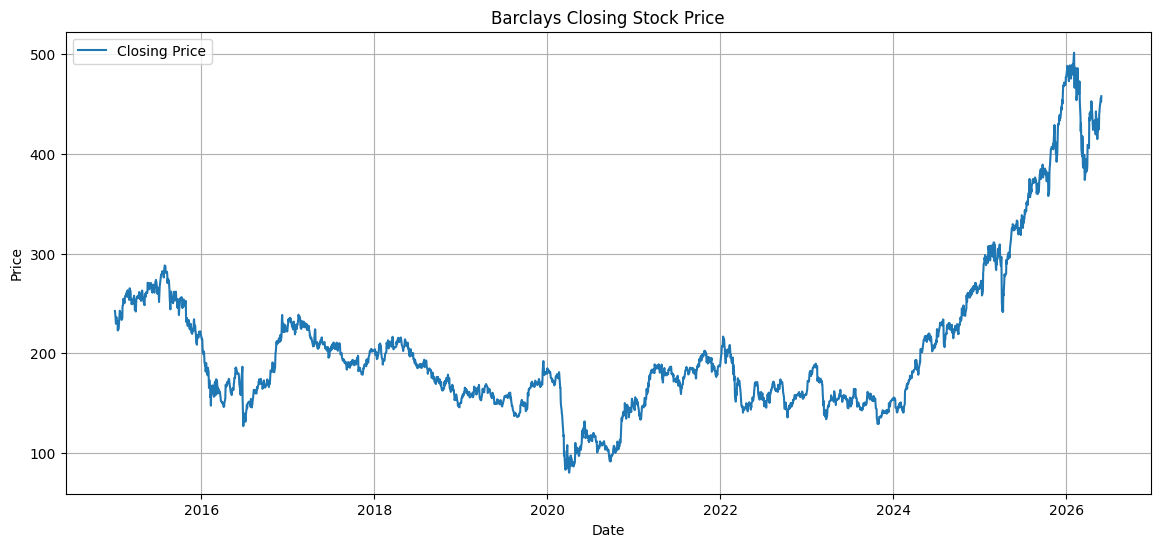

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(barclays_series.index, barclays_series, label="Closing Price")
plt.title("Barclays Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

### Check Stationarity (ADF Test) for Barclays

In [ ]:
barclays_is_stationary = adf_test(barclays_series)

ADF Test Results for :
ADF Statistic : 0.4577984653460698
p-value       : 0.9835323724387883

Critical Values:
1%: -3.43263213476853
5%: -2.862548291896071
10%: -2.5673067431757923

Conclusion: The  series is non-stationary (p-value > 0.05). Differencing may be required.


### First-Order Differencing for Barclays (if non-stationary)

In [ ]:
if not barclays_is_stationary:
    barclays_series_diff = barclays_series.diff().dropna()
    print("Performed first-order differencing on Barclays series.")
    # Verify stationarity again if differenced
    print("\nADF Test on Differenced Barclays Series:")
    adf_test(barclays_series_diff)
else:
    barclays_series_diff = barclays_series.copy()
    print("Barclays series is already stationary, no differencing applied.")

Performed first-order differencing on Barclays series.

ADF Test on Differenced Barclays Series:
ADF Test Results for :
ADF Statistic : -16.123132410757577
p-value       : 4.873665645591908e-29

Critical Values:
1%: -3.43263213476853
5%: -2.862548291896071
10%: -2.5673067431757923

Conclusion: The  series is stationary (p-value <= 0.05).


### Visualize Differenced Series for Barclays

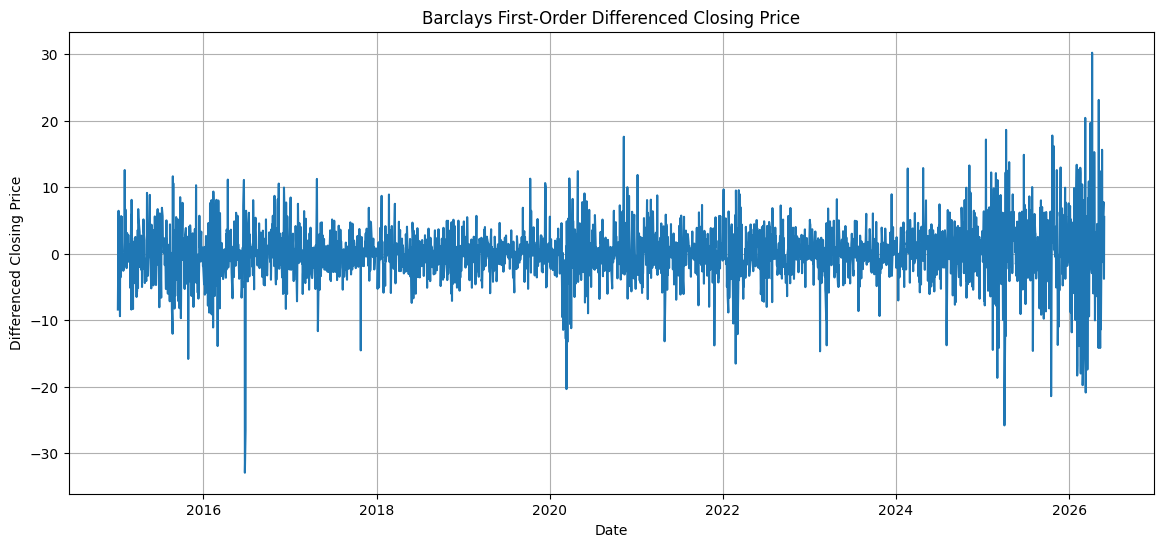

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(barclays_series_diff)
plt.title("Barclays First-Order Differenced Closing Price")
plt.xlabel("Date")
plt.ylabel("Differenced Closing Price")
plt.grid(True)
plt.show()

### ACF and PACF Analysis for Differenced Barclays Series

<Figure size 1200x500 with 0 Axes>

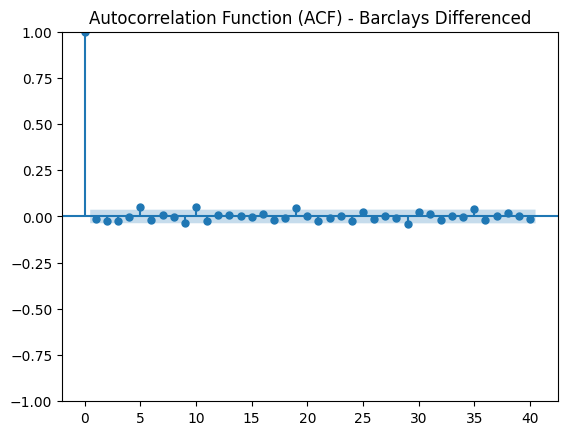

<Figure size 1200x500 with 0 Axes>

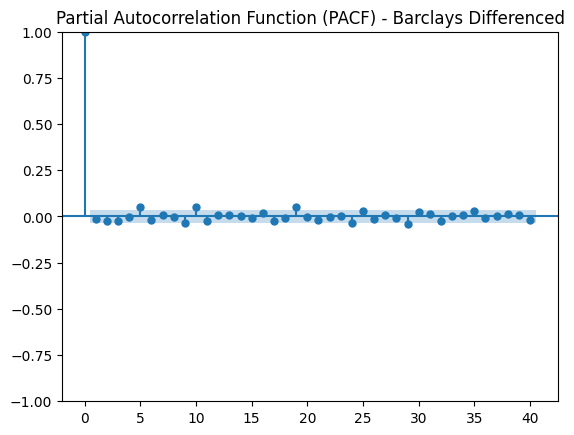

In [ ]:
# ACF Plot
plt.figure(figsize=(12,5))
plot_acf(barclays_series_diff, lags=40)
plt.title("Autocorrelation Function (ACF) - Barclays Differenced")
plt.show()

# PACF Plot
plt.figure(figsize=(12,5))
plot_pacf(barclays_series_diff, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) - Barclays Differenced")
plt.show()

### Train-Test Split for Barclays

In [ ]:
barclays_train_size = int(len(barclays_series) * 0.8)
barclays_train = barclays_series[:barclays_train_size]
barclays_test = barclays_series[barclays_train_size:]

print("Barclays Training samples :", len(barclays_train))
print("Barclays Testing samples  :", len(barclays_test))

Barclays Training samples : 2304
Barclays Testing samples  : 576


### Grid Search for Best ARIMA Model for Barclays

In [ ]:
barclays_best_model, barclays_best_order, barclays_best_aic = find_best_arima(barclays_train)

Best ARIMA Order : (0, 1, 0)
Lowest AIC       : 12349.999094585393


### Forecast for Barclays

In [ ]:
barclays_forecast = forecast_arima(barclays_train, barclays_test, barclays_best_order)

ARIMA(0, 1, 0) walk-forward:   0%|          | 0/576 [00:00<?, ?it/s]

### Evaluation for Barclays

In [ ]:
barclays_metrics = evaluate_model(barclays_test, barclays_forecast)
barclays_metrics["Bank"] = "Barclays"
barclays_metrics["Best Order"] = barclays_best_order
barclays_metrics["AIC"] = barclays_best_aic

### Actual vs Predicted Plot for Barclays

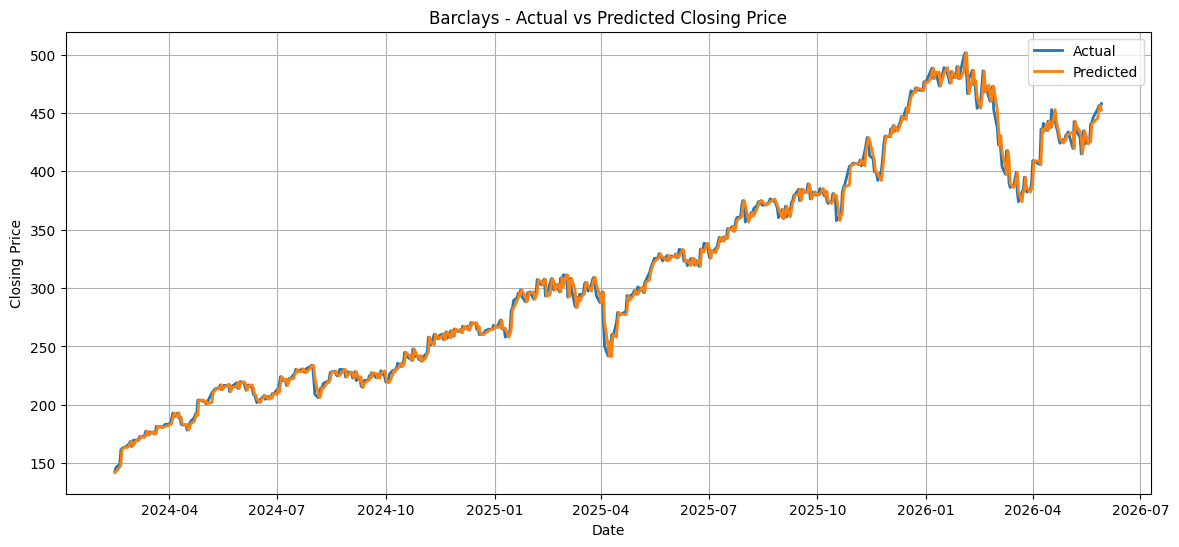

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(barclays_test.index, barclays_test, label="Actual", linewidth=2)
plt.plot(barclays_test.index, barclays_forecast, label="Predicted", linewidth=2)
plt.title("Barclays - Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

### Residual Analysis for Barclays

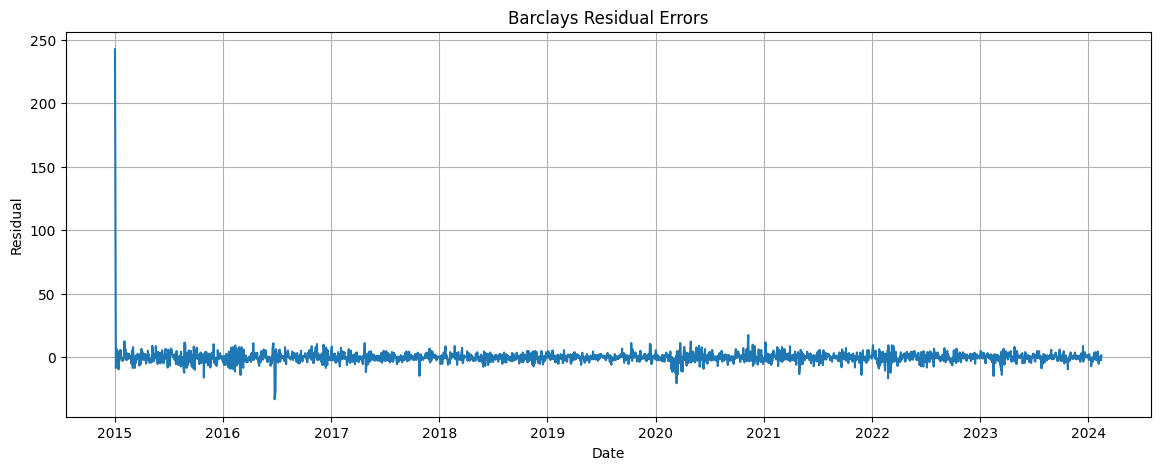

In [ ]:
barclays_residuals = barclays_best_model.resid

plt.figure(figsize=(14,5))
plt.plot(barclays_residuals)
plt.title("Barclays Residual Errors")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

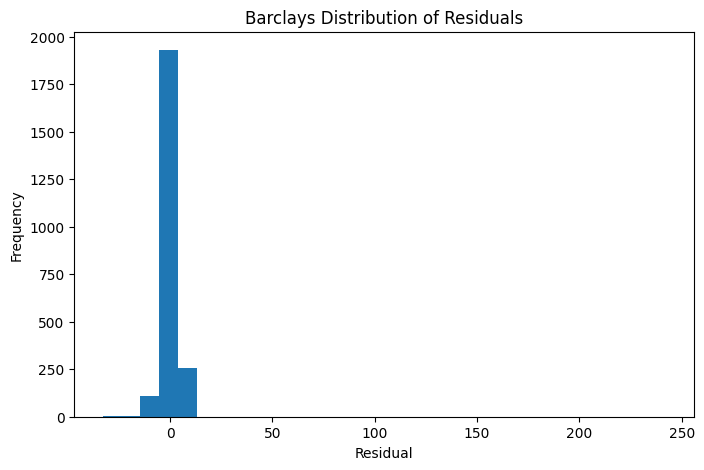

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(barclays_residuals, bins=30)
plt.title("Barclays Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

<Figure size 1000x400 with 0 Axes>

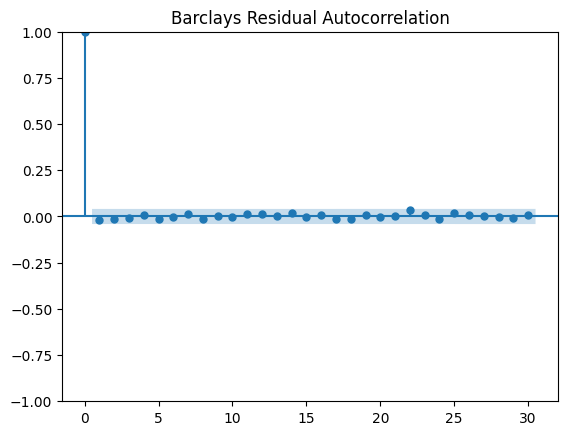

In [ ]:
plt.figure(figsize=(10,4))
plot_acf(barclays_residuals, lags=30)
plt.title("Barclays Residual Autocorrelation")
plt.show()

## ARIMA Model for Goldman Sachs

In [ ]:
# Select closing price for Goldman Sachs
goldman_series = goldman['Close']

print("Goldman Sachs Series Info:")
goldman_series.info()
print("\nGoldman Sachs Series Head:\n", goldman_series.head())

Goldman Sachs Series Info:
<class 'pandas.core.series.Series'>
DatetimeIndex: 2868 entries, 2015-01-02 to 2026-05-29
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
2868 non-null   float64
dtypes: float64(1)
memory usage: 44.8 KB

Goldman Sachs Series Head:
 Date
2015-01-02    155.555191
2015-01-05    150.698364
2015-01-06    147.649841
2015-01-07    149.850189
2015-01-08    152.242554
Name: Close, dtype: float64


### Plot Goldman Sachs Closing Price

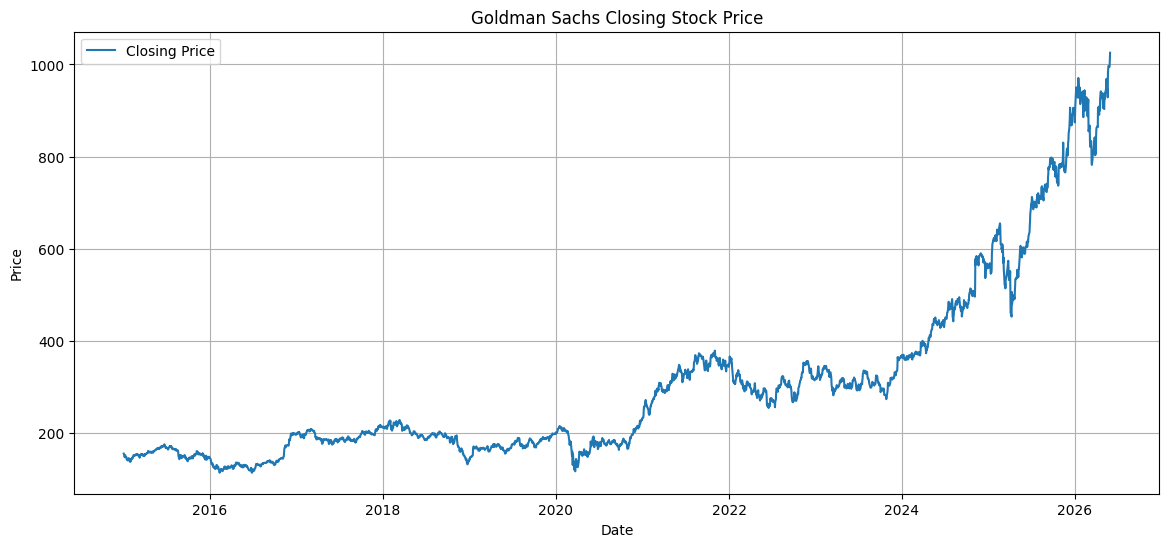

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(goldman_series.index, goldman_series, label="Closing Price")
plt.title("Goldman Sachs Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

### Check Stationarity (ADF Test) for Goldman Sachs

In [ ]:
goldman_is_stationary = adf_test(goldman_series)

ADF Test Results for :
ADF Statistic : 2.939000964640951
p-value       : 1.0

Critical Values:
1%: -3.4326538431271962
5%: -2.8625578793668107
10%: -2.567311847496079

Conclusion: The  series is non-stationary (p-value > 0.05). Differencing may be required.


### First-Order Differencing for Goldman Sachs (if non-stationary)

In [ ]:
if not goldman_is_stationary:
    goldman_series_diff = goldman_series.diff().dropna()
    print("Performed first-order differencing on Goldman Sachs series.")
    # Verify stationarity again if differenced
    print("\nADF Test on Differenced Goldman Sachs Series:")
    adf_test(goldman_series_diff)
else:
    goldman_series_diff = goldman_series.copy()
    print("Goldman Sachs series is already stationary, no differencing applied.")

Performed first-order differencing on Goldman Sachs series.

ADF Test on Differenced Goldman Sachs Series:
ADF Test Results for :
ADF Statistic : -10.205904296348548
p-value       : 5.80561360095528e-18

Critical Values:
1%: -3.4326562806874334
5%: -2.8625589559080318
10%: -2.567312420641838

Conclusion: The  series is stationary (p-value <= 0.05).


### Visualize Differenced Series for Goldman Sachs

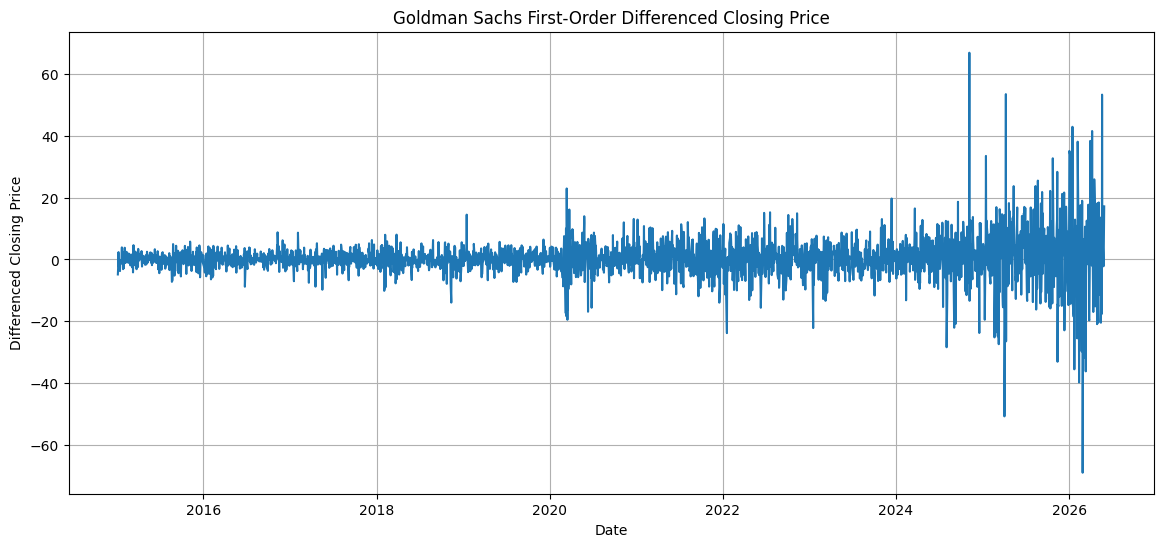

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(goldman_series_diff)
plt.title("Goldman Sachs First-Order Differenced Closing Price")
plt.xlabel("Date")
plt.ylabel("Differenced Closing Price")
plt.grid(True)
plt.show()

### ACF and PACF Analysis for Differenced Goldman Sachs Series

<Figure size 1200x500 with 0 Axes>

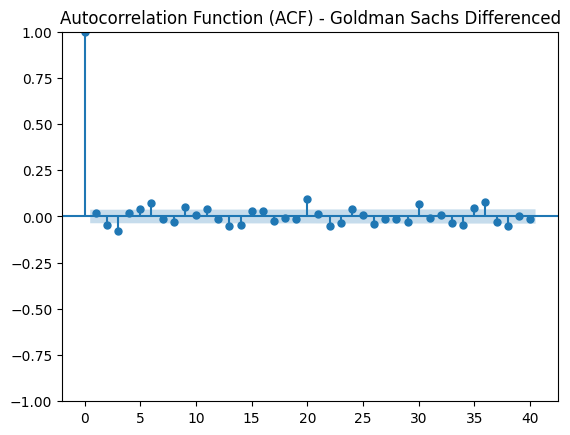

<Figure size 1200x500 with 0 Axes>

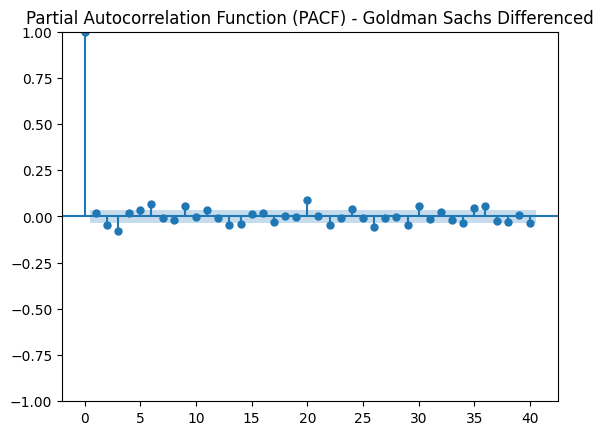

In [ ]:
# ACF Plot
plt.figure(figsize=(12,5))
plot_acf(goldman_series_diff, lags=40)
plt.title("Autocorrelation Function (ACF) - Goldman Sachs Differenced")
plt.show()

# PACF Plot
plt.figure(figsize=(12,5))
plot_pacf(goldman_series_diff, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) - Goldman Sachs Differenced")
plt.show()

### Train-Test Split for Goldman Sachs

In [ ]:
goldman_train_size = int(len(goldman_series) * 0.8)
goldman_train = goldman_series[:goldman_train_size]
goldman_test = goldman_series[goldman_train_size:]

print("Goldman Sachs Training samples :", len(goldman_train))
print("Goldman Sachs Testing samples  :", len(goldman_test))

Goldman Sachs Training samples : 2294
Goldman Sachs Testing samples  : 574


### Grid Search for Best ARIMA Model for Goldman Sachs

In [ ]:
goldman_best_model, goldman_best_order, goldman_best_aic = find_best_arima(goldman_train)

Best ARIMA Order : (3, 1, 5)
Lowest AIC       : 12768.65045292332


### Forecast for Goldman Sachs

In [ ]:
goldman_forecast = forecast_arima(goldman_train, goldman_test, goldman_best_order)

ARIMA(3, 1, 5) walk-forward:   0%|          | 0/574 [00:00<?, ?it/s]

⚠ 2 of 574 forecasts diverged and were replaced with a persistence fallback: [(45, np.float64(-724228.8462935118)), (246, np.float64(-1534510.3356056188))]


### Diagnosing & Fixing the Goldman Sachs Divergence

In [ ]:
# Your original run showed Goldman Sachs' R2 at roughly -2.1 billion — a sign that at
# least one walk-forward step diverged to an absurd forecast and dominated every metric.
# Re-running with the guarded forecast_arima() catches and replaces any such step,
# and refit_every=5 also cuts the runtime by roughly 5x versus refitting every day.
goldman_forecast = forecast_arima(
    goldman_train, goldman_test, goldman_best_order,
    refit_every=5, max_jump=0.5
)

print("Diverged steps replaced:", len(goldman_forecast.diverged_steps))

ARIMA(3, 1, 5) walk-forward:   0%|          | 0/574 [00:00<?, ?it/s]

⚠ 5 of 574 forecasts diverged and were replaced with a persistence fallback: [(45, np.float64(-724228.8462935118)), (46, np.float64(-724228.8462935118)), (47, np.float64(-724228.8462935118)), (48, np.float64(-724228.8462935118)), (49, np.float64(-724228.8462935118))]
Diverged steps replaced: 5


### Evaluation for Goldman Sachs

In [ ]:
goldman_metrics = evaluate_model(goldman_test, goldman_forecast)
goldman_metrics["Bank"] = "Goldman Sachs"
goldman_metrics["Best Order"] = goldman_best_order
goldman_metrics["AIC"] = goldman_best_aic

### Actual vs Predicted Plot for Goldman Sachs

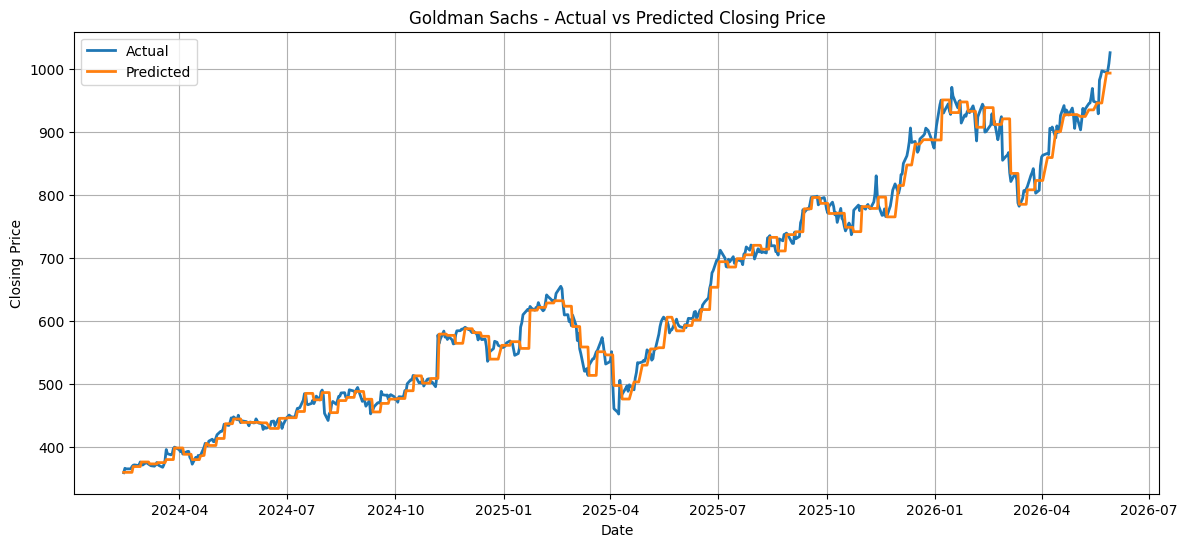

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(goldman_test.index, goldman_test, label="Actual", linewidth=2)
plt.plot(goldman_test.index, goldman_forecast, label="Predicted", linewidth=2)
plt.title("Goldman Sachs - Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

### Residual Analysis for Goldman Sachs

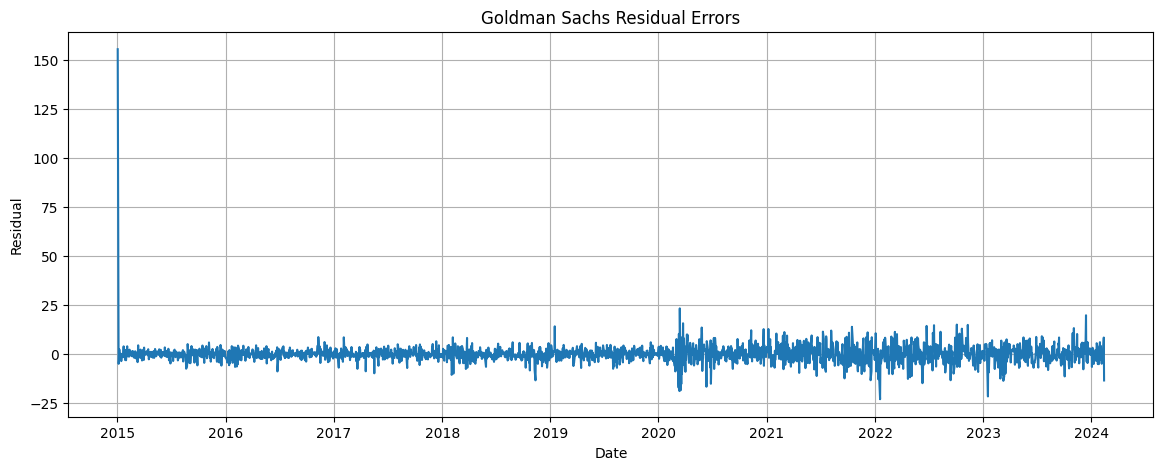

In [ ]:
goldman_residuals = goldman_best_model.resid

plt.figure(figsize=(14,5))
plt.plot(goldman_residuals)
plt.title("Goldman Sachs Residual Errors")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

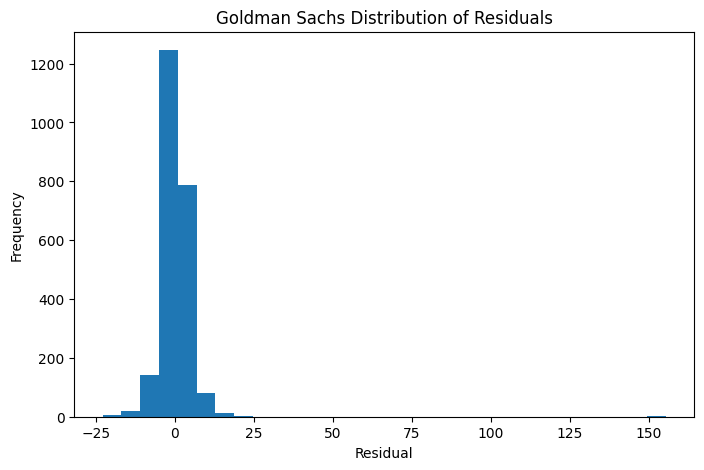

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(goldman_residuals, bins=30)
plt.title("Goldman Sachs Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

<Figure size 1000x400 with 0 Axes>

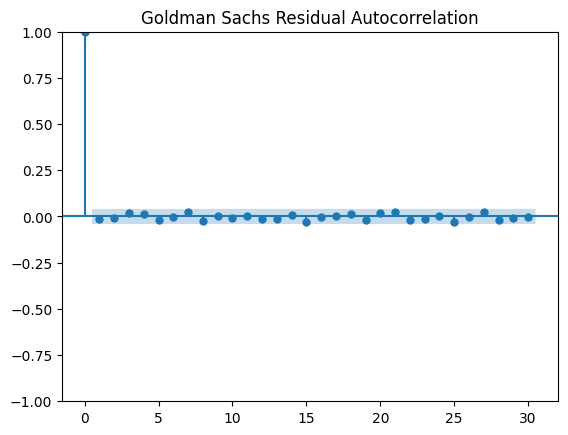

In [ ]:
plt.figure(figsize=(10,4))
plot_acf(goldman_residuals, lags=30)
plt.title("Goldman Sachs Residual Autocorrelation")
plt.show()

## Comparison of ARIMA Models

In [ ]:
lloyds_metrics = evaluate_model(test, forecast)
lloyds_metrics["Bank"] = "Lloyds"
lloyds_metrics["Best Order"] = best_order
lloyds_metrics["AIC"] = best_aic

all_results = pd.DataFrame([
    lloyds_metrics,
    barclays_metrics,
    goldman_metrics
])

print("\nComparison of ARIMA Model Performance:\n")
print(all_results)


Comparison of ARIMA Model Performance:

         MAE       RMSE      MAPE        R2           Bank Best Order  \
0   0.902233   1.294151  1.215235  0.994798         Lloyds  (4, 1, 2)   
1   4.614249   6.395007  1.467562  0.995291       Barclays  (0, 1, 0)   
2  13.734217  19.185795  2.148869  0.988640  Goldman Sachs  (3, 1, 5)   

            AIC  
0   6512.631843  
1  12349.999095  
2  12768.650453  


### Visualizing Comparison of Metrics

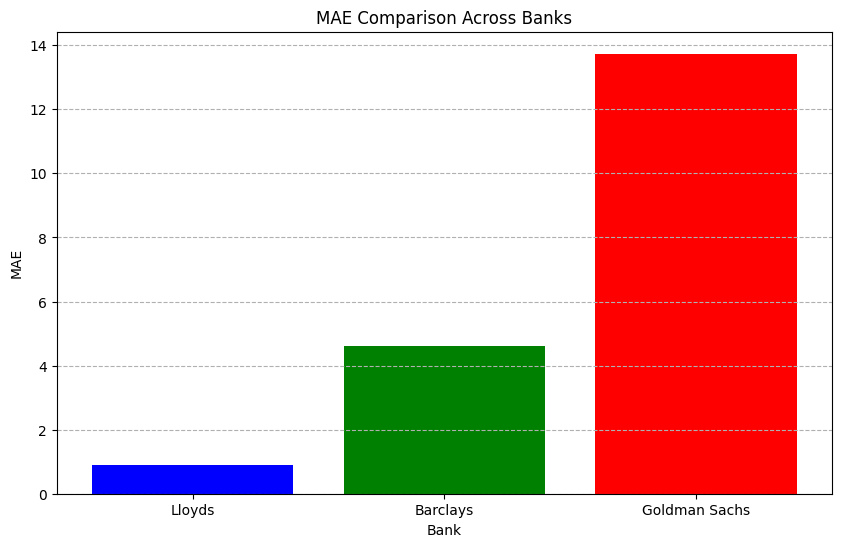

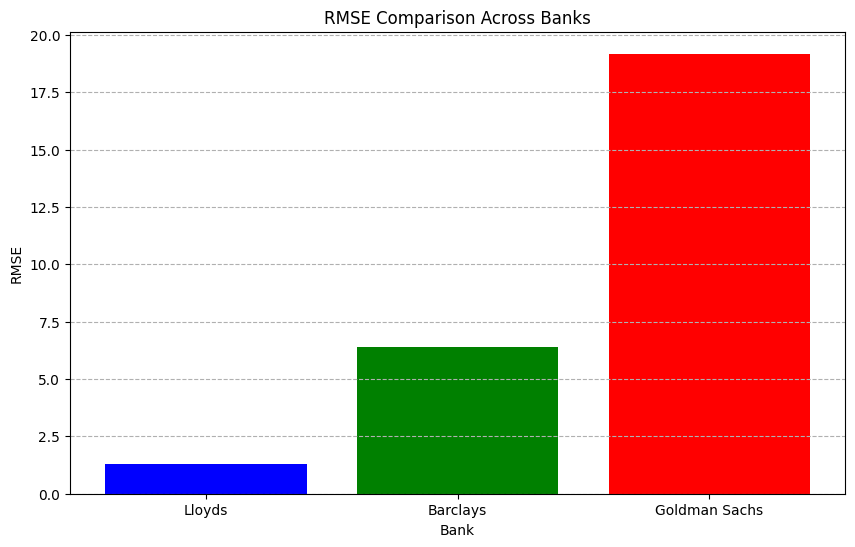

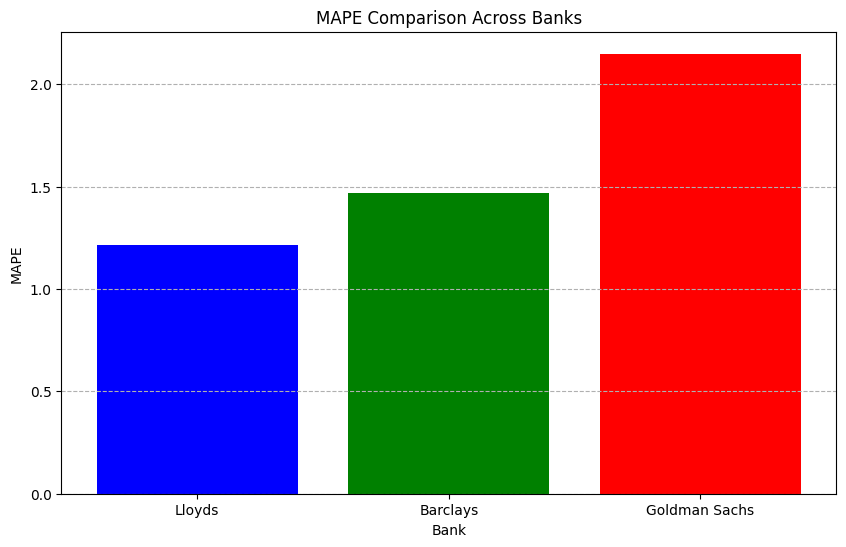

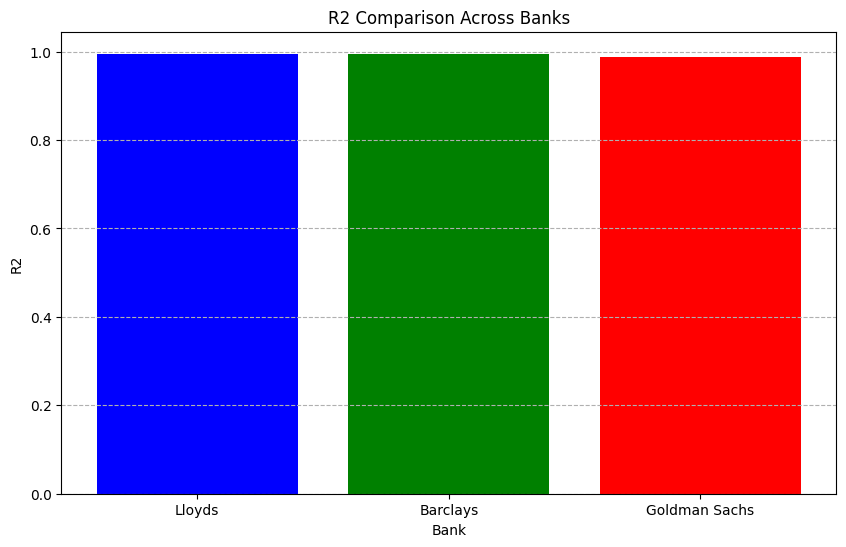

In [ ]:
metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'R2']

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(all_results['Bank'], all_results[metric], color=['blue', 'green', 'red'])
    plt.xlabel('Bank')
    plt.ylabel(metric)
    plt.title(f'{metric} Comparison Across Banks')
    plt.grid(axis='y', linestyle='--')
    plt.show()

### Comparison Table (Heatmap)

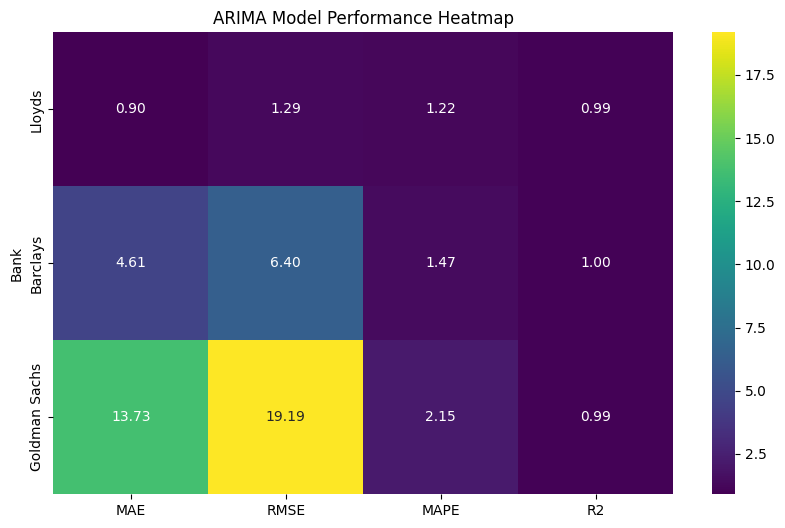

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(all_results.set_index('Bank')[['MAE', 'RMSE', 'MAPE', 'R2']], annot=True, cmap='viridis', fmt=".2f")
plt.title('ARIMA Model Performance Heatmap')
plt.show()

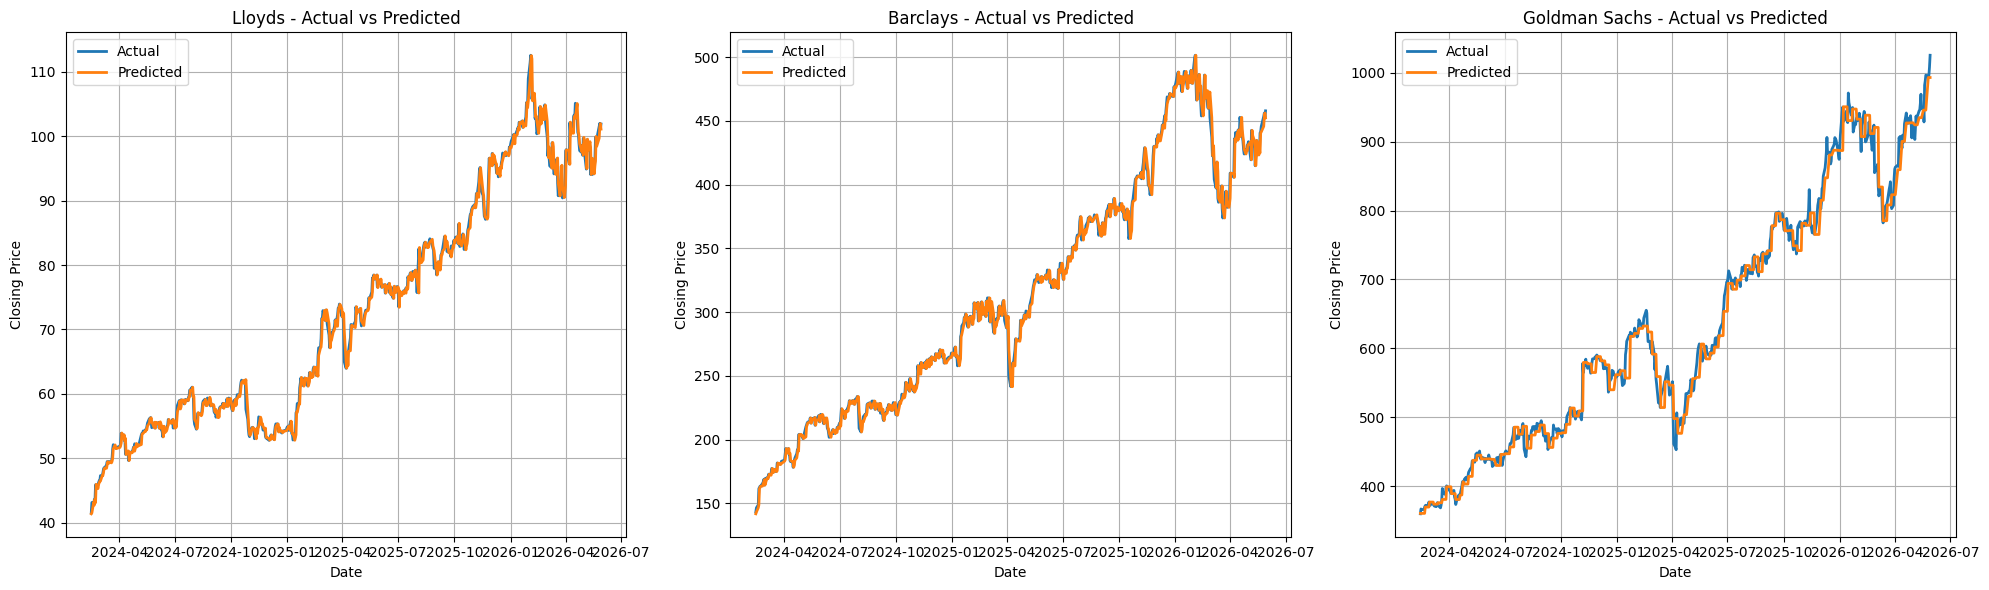

In [ ]:
import matplotlib.pyplot as plt

# Ensure train/test series exist if this comparison cell is run directly.
if 'barclays_test' not in globals():
    barclays_train_size = int(len(barclays_series) * 0.8)
    barclays_train = barclays_series[:barclays_train_size]
    barclays_test = barclays_series[barclays_train_size:]

if 'goldman_test' not in globals():
    goldman_train_size = int(len(goldman_series) * 0.8)
    goldman_train = goldman_series[:goldman_train_size]
    goldman_test = goldman_series[goldman_train_size:]

plt.figure(figsize=(20, 6))

# Plot for Lloyds
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast, label="Predicted", linewidth=2)
plt.title("Lloyds - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

# Plot for Barclays
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
plt.plot(barclays_test.index, barclays_test, label="Actual", linewidth=2)
plt.plot(barclays_test.index, barclays_forecast, label="Predicted", linewidth=2)
plt.title("Barclays - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

# Plot for Goldman Sachs
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
plt.plot(goldman_test.index, goldman_test, label="Actual", linewidth=2)
plt.plot(goldman_test.index, goldman_forecast, label="Predicted", linewidth=2)
plt.title("Goldman Sachs - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()